# EDA and Data Cleaning
This notebook cleans the Awesome Inc Superstore datasets and provides example EDA and SQL-based analytics against the generated data warehouse (`dw.db`).
Run cells in order. Cleaned CSVs are written to `data/` and the OLTP/DW scripts produce `oltp.db` / `dw.db`.

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set(); pd.set_option('display.max_columns', None)

In [3]:
data_dir = Path('../data')
orders_path = data_dir / 'Awesome_Inc_Superstore_Orders.csv'
returns_path = data_dir / 'Awesome_Inc_Superstore_Returns.csv'
# Read with latin1 encoding to avoid decode errors
orders = pd.read_csv(orders_path, encoding='latin1', low_memory=False)
returns = pd.read_csv(returns_path, encoding='latin1', low_memory=False)
print('Orders shape:', orders.shape)
print('Returns shape:', returns.shape)
orders.head()

Orders shape: (51290, 24)
Returns shape: (1079, 3)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,Oklahoma,United States,Central US,USCA,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,$221.98,2,0.0,$62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black","$3,709.40",9,0.1,-$288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID","$5,175.17",9,0.1,$919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless","$2,892.51",5,0.1,-$96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed","$2,832.96",8,0.0,$311.52,903.04,Critical


In [4]:
def clean_orders(df):
    df = df.copy()
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')
    str_cols = ['Order ID','Ship Mode','Customer ID','Customer Name','Segment','Postal Code','City','State','Country','Region','Market','Product ID','Category','Sub-Category','Product Name','Order Priority']
    for c in str_cols:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip()
    for col in ['Sales','Quantity','Discount','Profit','Shipping Cost']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

orders_clean = clean_orders(orders)
returns_clean = returns.copy()
if list(returns_clean.columns[:3]) == ['Returned','Order ID','Region']:
    returns_clean = returns_clean.rename(columns={returns_clean.columns[0]:'Returned', returns_clean.columns[1]:'Order ID'})

print('Missing values in orders:')
print(orders_clean.isna().sum().sort_values(ascending=False).head(10))

orders_clean.head()

Missing values in orders:
Profit           51290
Sales            51290
Row ID               0
Order ID             0
Shipping Cost        0
Discount             0
Quantity             0
Product Name         0
Sub-Category         0
Category             0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,Oklahoma,United States,Central US,USCA,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,NaN,2,0.0,NaN,40.77,High
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,nan,Wollongong,New South Wales,Australia,Oceania,Asia Pacific,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",NaN,9,0.1,NaN,923.63,Critical
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,nan,Brisbane,Queensland,Australia,Oceania,Asia Pacific,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",NaN,9,0.1,NaN,915.49,Medium
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,nan,Berlin,Berlin,Germany,Western Europe,Europe,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",NaN,5,0.1,NaN,910.16,Medium
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,nan,Dakar,Dakar,Senegal,Western Africa,Africa,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",NaN,8,0.0,NaN,903.04,Critical


In [5]:
# Save cleaned CSVs for reproducibility and for the ETL scripts to consume
out_dir = Path('../data')
orders_clean.to_csv(out_dir / 'cleaned_orders.csv', index=False)
returns_clean.to_csv(out_dir / 'cleaned_returns.csv', index=False)
print('Wrote cleaned_orders.csv and cleaned_returns.csv to', out_dir)

Wrote cleaned_orders.csv and cleaned_returns.csv to ../data


Category
Furniture          0.0
Office Supplies    0.0
Technology         0.0
Name: Sales, dtype: float64

/var/folders/tp/2_p5rfjs6b51n88xdcx3t3p80000gn/T/ipykernel_4458/3389226247.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = orders_clean.set_index('Order Date').resample('M')['Sales'].sum().dropna()


Order Date
2012-01-31    0.0
2012-02-29    0.0
2012-03-31    0.0
2012-04-30    0.0
2012-05-31    0.0
Freq: ME, Name: Sales, dtype: float64

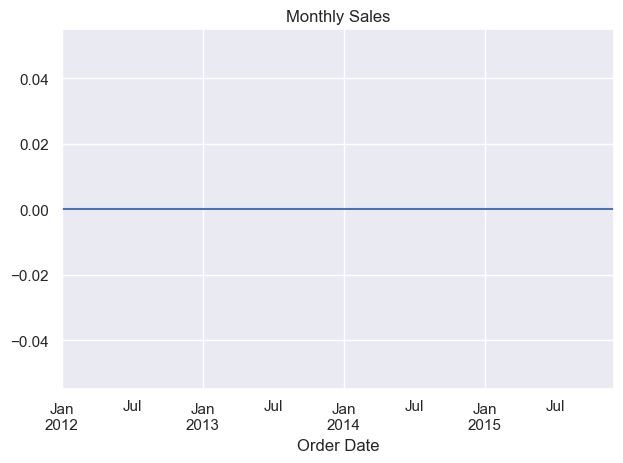

In [6]:
# Basic EDA: Sales by Category and Monthly Sales
if 'Category' in orders_clean.columns and 'Sales' in orders_clean.columns:
    cat_sales = orders_clean.groupby('Category', dropna=False)['Sales'].sum().sort_values(ascending=False)
    display(cat_sales)
    cat_sales.plot(kind='bar', title='Sales by Category'); plt.tight_layout()

if 'Order Date' in orders_clean.columns and 'Sales' in orders_clean.columns:
    monthly = orders_clean.set_index('Order Date').resample('M')['Sales'].sum().dropna()
    display(monthly.head())
    monthly.plot(title='Monthly Sales'); plt.tight_layout()

## Example SQL analysis (run against `dw.db`)
The following cells run example SQL queries against the data warehouse `dw.db`:
- Sales by month
- Returns rate by region
- Top products by sales

,year,month,total_sales,month_str
0,2012,1,181251.76,2012-01
1,2012,2,182495.39,2012-02
2,2012,3,264055.25,2012-03
3,2012,4,232880.16,2012-04
4,2012,5,294075.36,2012-05


,region,num_returns,num_orders,return_rate
0,Western Europe,121,2993,0.040428
1,Central America,117,2831,0.041328
2,Oceania,78,1743,0.044750
3,Western US,72,1611,0.044693
4,Eastern US,69,1401,0.049251
5,Southeastern Asia,64,1517,0.042189
6,South America,61,1457,0.041867
7,Southern Asia,58,1346,0.043091
8,Southern Europe,55,1098,0.050091
9,Eastern Asia,53,1162,0.045611


,product_name,total_sales
0,"Cisco Smart Phone, Full Size",169326.81
1,"Apple Smart Phone, Full Size",154540.13
2,"Nokia Smart Phone, Full Size",134223.22
3,Canon imageCLASS 2200 Advanced Copier,123199.66
4,"Hon Executive Leather Armchair, Adjustable",122667.34
5,"Motorola Smart Phone, Full Size",120678.50
6,"Office Star Executive Leather Armchair, Adjust...",106196.28
7,"SAFCO Executive Leather Armchair, Black",91241.55
8,"Harbour Creations Executive Leather Armchair, ...",88838.79
9,"Cisco Smart Phone, with Caller ID",83834.33


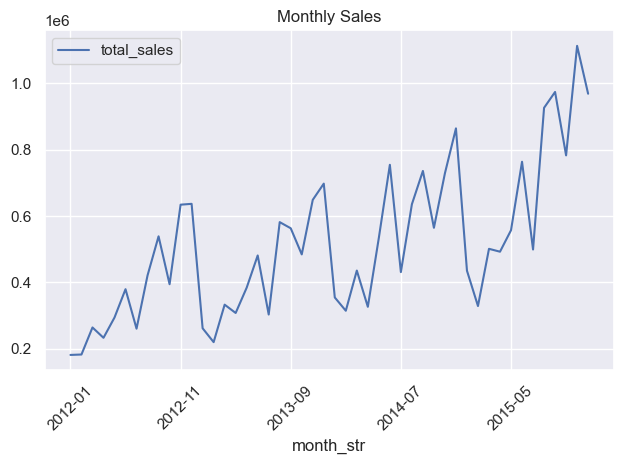

In [10]:
import sqlite3
from sqlalchemy import create_engine
dw_path = Path('../dw.db')
engine = create_engine(f'sqlite:///{dw_path}')
# 1) Sales by month (use dim_date + fact_sales)
q1 = '''
SELECT d.year, d.month, COALESCE(SUM(f.sales), 0) AS total_sales
FROM fact_sales f JOIN dim_date d ON f.date_key = d.date_key
GROUP BY d.year, d.month
ORDER BY d.year, d.month;
'''
monthly_sales = pd.read_sql_query(q1, engine)
# Ensure numeric and fill missing with 0 to allow plotting
monthly_sales['total_sales'] = pd.to_numeric(monthly_sales['total_sales'], errors='coerce').fillna(0.0)
monthly_sales['month_str'] = monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str).str.zfill(2)
display(monthly_sales.head())
monthly_sales.plot(x='month_str', y='total_sales', kind='line', title='Monthly Sales'); plt.xticks(rotation=45); plt.tight_layout()

# 2) Returns rate by region: join fact_sales.order_id with returns (if returns table exists in oltp, we can read it from oltp.db)
oltp_engine = create_engine('sqlite:///../oltp.db')
# Build returns rate per region by joining OLTP returns -> orders -> order_items -> (map to region through orders)
q2 = '''
SELECT o.region, SUM(CASE WHEN r.returned_flag IS NOT NULL THEN 1 ELSE 0 END) AS num_returns, COUNT(DISTINCT o.order_id) AS num_orders
FROM orders o LEFT JOIN returns r ON o.order_id = r.order_id
GROUP BY o.region
ORDER BY num_returns DESC;
'''
returns_by_region = pd.read_sql_query(q2, oltp_engine)
returns_by_region['num_returns'] = pd.to_numeric(returns_by_region['num_returns'], errors='coerce').fillna(0).astype(int)
returns_by_region['num_orders'] = pd.to_numeric(returns_by_region['num_orders'], errors='coerce').fillna(0).astype(int)
returns_by_region['return_rate'] = returns_by_region.apply(lambda r: (r['num_returns']/r['num_orders']) if r['num_orders']>0 else 0.0, axis=1)
display(returns_by_region)

# 3) Top products by sales (fact_sales + dim_product)
q3 = '''
SELECT p.product_name, SUM(f.sales) AS total_sales
FROM fact_sales f JOIN dim_product p ON f.product_key = p.product_key
GROUP BY p.product_name
ORDER BY total_sales DESC
LIMIT 20;
'''
top_products = pd.read_sql_query(q3, engine)
display(top_products)

In [11]:
# Additional interactive visualizations with Plotly
import plotly.express as px
# Monthly sales (DW)
monthly_df = monthly_sales.copy()
monthly_df['month_dt'] = pd.to_datetime(monthly_df['month_str'])
fig = px.line(monthly_df, x='month_dt', y='total_sales', title='Monthly Sales (DW)')
fig.show()

# Top products (bar)
fig2 = px.bar(top_products, x='product_name', y='total_sales', title='Top Products by Sales', labels={'product_name':'Product','total_sales':'Sales'})
fig2.update_layout(xaxis_tickangle=-45)
fig2.show()

# Returns by region (from returns_by_region DataFrame)
if 'returns_by_region' in globals():
    fig3 = px.bar(returns_by_region.sort_values('return_rate', ascending=False), x='region', y='return_rate', title='Returns Rate by Region', labels={'region':'Region','return_rate':'Return Rate'})
    fig3.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [12]:
# Save interactive charts as static PNGs (optional)
# Requires kaleido for static image export; try if available
try:
    fig.write_image('../reports/monthly_sales.png')
    fig2.write_image('../reports/top_products.png')
except Exception as e:
    print('Could not write images (kaleido not installed):', e)

Could not write images (kaleido not installed): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido

